# Lab 3 - Part 1: Text Visualization & Classical Representations


**Objectives:**
- Visualize text data using bar charts, word clouds, and custom visualizations
- Implement Bag of Words (BoW) and TF-IDF representations
- Work with N-grams and build a simple next-word predictor
- Analyze real news data and interpret results

---

## Instructions

1. Complete all exercises marked with `# YOUR CODE HERE`
2. **Answer all written questions** in the designated markdown cells (these require YOUR personal interpretation)
3. Save your completed notebook
4. **Push to your Git repository and send the link to: yoroba93@gmail.com**

### Important: Personal Interpretation Questions

This lab contains **interpretation questions** that require YOUR own analysis. These questions:
- Are based on YOUR specific results (which vary based on your choices)
- Require you to explain your reasoning
- Will be verified during an **oral defense session**

---

## Setup

In [102]:
# Install required libraries (uncomment if needed)
# !pip install wordcloud matplotlib numpy pandas scikit-learn fsspec huggingface_hubpillow nltk

In [103]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
import re
import string

import nltk
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

print("Setup complete!")

Setup complete!


---

## Part A: Loading and Exploring the 20 Newsgroups Dataset (15 min)

We will use the 20 Newsgroups dataset from Hugging Face. This dataset contains news articles from 20 different categories.

In [104]:
# Load the dataset
import pandas as pd
splits = {'train': 'train.jsonl', 'test': 'test.jsonl'}
## TODO: check on https://huggingface.co/datasets/SetFit/20_newsgroups how to load with pandas
df = pd.read_json("hf://datasets/SetFit/20_newsgroups/" + splits["train"], lines=True)

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
print(f"\nLabel distribution:")
print(df['label_text'].value_counts())

Dataset shape: (11314, 3)

Columns: ['text', 'label', 'label_text']

Label distribution:
label_text
rec.sport.hockey            600
soc.religion.christian      599
rec.motorcycles             598
rec.sport.baseball          597
sci.crypt                   595
rec.autos                   594
sci.med                     594
sci.space                   593
comp.windows.x              593
comp.os.ms-windows.misc     591
sci.electronics             591
comp.sys.ibm.pc.hardware    590
misc.forsale                585
comp.graphics               584
comp.sys.mac.hardware       578
talk.politics.mideast       564
talk.politics.guns          546
alt.atheism                 480
talk.politics.misc          465
talk.religion.misc          377
Name: count, dtype: int64


In [105]:
# View sample data
print("Sample document:")
print("="*50)
print(f"Label: {df.iloc[0]['label_text']}")
print(f"Text (first 500 chars): {df.iloc[0]['text'][:500]}...")

Sample document:
Label: rec.autos
Text (first 500 chars): I was wondering if anyone out there could enlighten me on this car I saw
the other day. It was a 2-door sports car, looked to be from the late 60s/
early 70s. It was called a Bricklin. The doors were really small. In addition,
the front bumper was separate from the rest of the body. This is 
all I know. If anyone can tellme a model name, engine specs, years
of production, where this car is made, history, or whatever info you
have on this funky looking car, please e-mail....


### Exercise A.1: Select YOUR Categories

**Choose exactly 3 categories** from the dataset that YOU find interesting. This choice is personal and will affect all your subsequent analysis.

**Available categories:**
- alt.atheism, comp.graphics, ...

In [130]:
# TODO: Choose YOUR 3 categories (this affects all your analysis!)
# YOUR CODE HERE
my_categories = ["comp.graphics", "talk.politics.mideast", "comp.windows.x"]  # Replace with your choices

# Filter the dataset
df_filtered = df[df['label_text'].isin(my_categories)].copy()
df_filtered = df_filtered.reset_index(drop=True)

print(f"Selected categories: {my_categories}")
print(f"Filtered dataset size: {len(df_filtered)}")
print(f"\nDistribution:")
print(df_filtered['label_text'].value_counts())


Selected categories: ['comp.graphics', 'talk.politics.mideast', 'comp.windows.x']
Filtered dataset size: 1741

Distribution:
label_text
comp.windows.x           593
comp.graphics            584
talk.politics.mideast    564
Name: count, dtype: int64


### Written Question A.1 (Personal Interpretation)

**Why did you choose these 3 specific categories?** Explain your reasoning (at least 3 sentences).

Consider:
- Are they related or completely different?
- What do you expect to find in terms of vocabulary differences?
- Why are they interesting to YOU?

**YOUR ANSWER:**

I chose <b>"comp.graphics"</b> because I'm interested in computer graphics and want to see the specific terminology used in that field. </br> 
<b>"talk.politics.mideast"</b> to explore the language used in political discussions about the Middle East, which is a complex and often controversial topic. 
Finally, <b>"comp.windows.x"</b> to compare with <b>"comp.graphics"</b> to see how the vocabulary differs between two closely related categories in the computing domain.</br> 
I expect to find technical jargon in the <b>"comp.graphics"</b> and <b>"comp.windows.x"</b> categories, while the <b>"talk.politics.mideast"</b> category will likely contain more political and geopolitical terms.</br> 
These categories are interesting to me because they represent different domains (technology vs. politics) and I want to analyze how language varies across these contexts.

...

---

## Part B: Text Preprocessing Function

Before visualization, we need to clean our text data.

In [107]:
# Example preprocessing function
# TODO: Complete the function as needed
def preprocess_text(text):
    """Basic text preprocessing."""
    # Lowercase
    text = text.lower()
    # Remove emails
    text = re.sub(r'\S+@\S+', '', text) 
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Test
sample = "Hello! Check this: http://example.com. Email me at test@email.com. Price: $100."
print(f"Original: {sample}")
print(f"Cleaned:  {preprocess_text(sample)}")

Original: Hello! Check this: http://example.com. Email me at test@email.com. Price: $100.
Cleaned:  hello check this email me at price


### Exercise B.1: Improve the Preprocessing Function

The function above is basic. **Improve it** by adding:
1. Stop word removal
2. Lemmatization
3. Minimum word length filter (remove words with < 3 characters)

In [108]:
# TODO: Complete this improved preprocessing function
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess_text_advanced(text):
    """
    Advanced text preprocessing with stop words removal and lemmatization.
    
    Args:
        text (str): Input text
    Returns:
        str: Preprocessed text
    """
    # YOUR CODE HERE
    # Step 1: Basic cleaning (lowercase, remove emails, URLs, numbers, punctuation)
    text = preprocess_text(text)
    
    # Step 2: Tokenize
    tokens = word_tokenize(text)
    
    # Step 3: Remove stop words
    tokens = [token for token in tokens if token not in stop_words]
    
    # Step 4: Lemmatize
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    # Step 5: Remove short words (< 3 chars)
    tokens = [token for token in tokens if len(token) >= 3]
    
    # Step 6: Join back to string
    return ' '.join(tokens)


# Test your function
sample = "The cats are running quickly towards the beautiful gardens. Email: test@mail.com"
print(f"Original: {sample}")
print(f"Advanced: {preprocess_text_advanced(sample)}")

Original: The cats are running quickly towards the beautiful gardens. Email: test@mail.com
Advanced: cat running quickly towards beautiful garden email


In [109]:
# Apply preprocessing to your filtered dataset
df_filtered['text_clean'] = df_filtered['text'].apply(preprocess_text_advanced)

# Show sample
print("Sample preprocessed document:")
print(df_filtered.iloc[0]['text_clean'][:300])

Sample preprocessed document:
weiteks addressphone number like get information chip


---

## Part C: Text Visualization

### C.1 Bar Chart: Top Words per Category

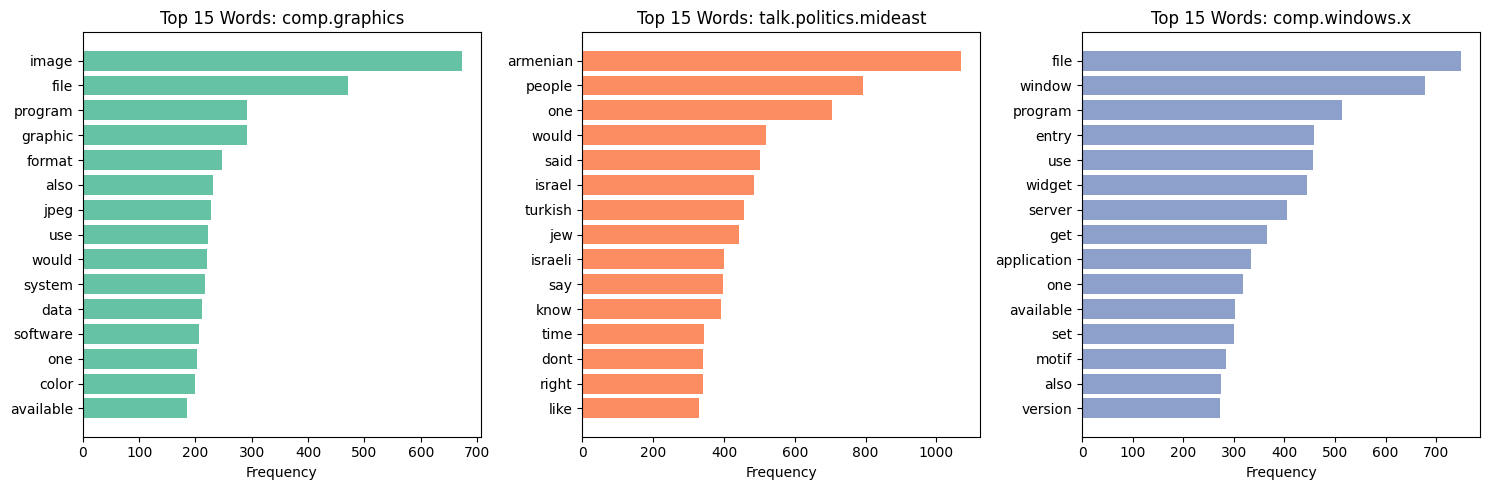

In [110]:
def get_top_words(texts, n=15):
    """Get the n most common words from a list of texts."""
    all_words = ' '.join(texts).split()
    word_counts = Counter(all_words)
    return word_counts.most_common(n)

# Get top words for each category
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    top_words = get_top_words(texts, 15)
    
    words, counts = zip(*top_words)
    axes[idx].barh(words, counts, color=plt.cm.Set2(idx))
    axes[idx].set_title(f'Top 15 Words: {category}')
    axes[idx].invert_yaxis()
    axes[idx].set_xlabel('Frequency')

plt.tight_layout()
plt.savefig('top_words_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question C.1 (Personal Interpretation)

Look at your bar charts above and answer:

1. **What words are UNIQUE to each category?** (List at least 2 per category)
2. **What words are SHARED across categories?** Why do you think they appear in multiple categories?
3. **Based ONLY on the top words, could you guess the topic of each category?** Explain.

**YOUR ANSWER:**

*Category 1 (comp.graphics):*
- Unique words:
- jpeg, graphics, image, file, color

*Category 2 (talk.politics.mideast):*
- Unique words:
- people,right, like

*Category 3 (comp.windows.x):*
- Unique words:
- window, program, server

*Shared words and explanation:*
one, use, get, also

*Topic guessing analysis:*
the first ans third categories are easy to guess based on the unique words, while the second category is more ambiguous and could be confused with other topics.

### C.2 Word Clouds

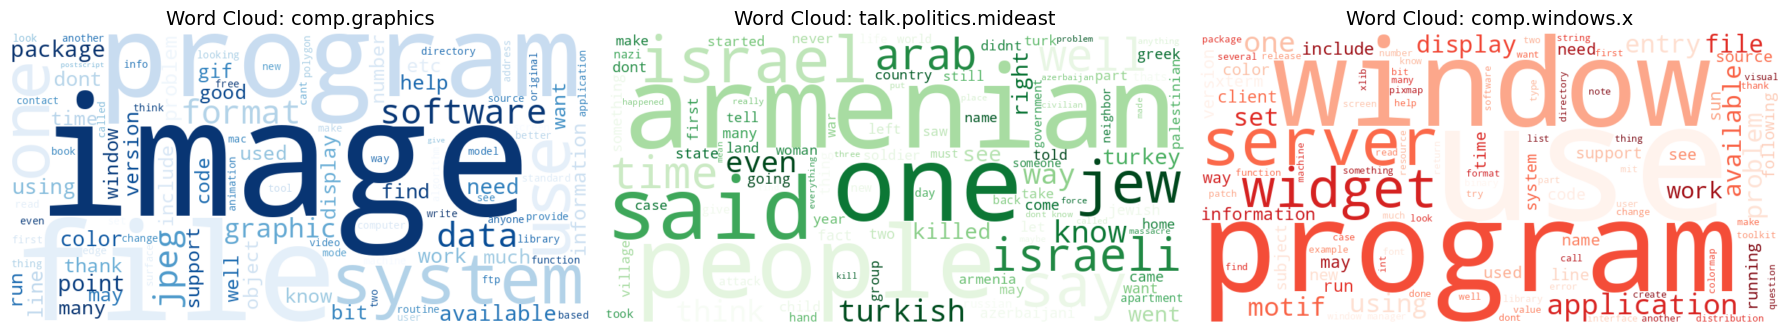

In [111]:
# Simple word cloud for each category
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

colors = ['Blues', 'Greens', 'Reds']

for idx, category in enumerate(my_categories):
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    text_combined = ' '.join(texts)
    
    wordcloud = WordCloud(
        width=800, 
        height=400,
        background_color='white',
        colormap=colors[idx],
        max_words=100,
        min_font_size=10
    ).generate(text_combined)
    
    axes[idx].imshow(wordcloud, interpolation='bilinear')
    axes[idx].set_title(f'Word Cloud: {category}', fontsize=14)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('wordclouds_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

### Exercise C.2: Custom Shaped Word Cloud

Create a word cloud using a **custom mask image**. 

**Instructions:**
1. Find or create a simple black & white silhouette image (PNG format)
2. Save it in your working directory
3. Use it as a mask for your word cloud

**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

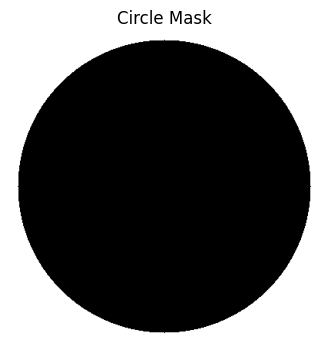

In [112]:
# Example: Creating a circular mask programmatically
# (You can replace this with your own image)

from PIL import Image

# Create a circular mask
def create_circle_mask(size=400):
    x = np.arange(0, size)
    y = np.arange(0, size)
    cx, cy = size // 2, size // 2
    r = size // 2 - 10
    mask = np.full((size, size), 255, dtype=np.uint8)
    for i in x:
        for j in y:
            if (i - cx)**2 + (j - cy)**2 <= r**2:
                mask[j, i] = 0
    return mask

circle_mask = create_circle_mask(400)
# Save the mask as an image
Image.fromarray(circle_mask).save('circle_mask.png')

# Show the mask
plt.figure(figsize=(4, 4))
plt.imshow(circle_mask, cmap='gray')
plt.title('Circle Mask')
plt.axis('off')
plt.show()

In [113]:
#Create a word cloud using a **custom mask image**. 

#**Instructions:**
#1. Find or create a simple black & white silhouette image (PNG format)
#2. Save it in your working directory
#3. Use it as a mask for your word cloud

#**Tip:** You can use any simple shape (circle, star, heart) or find free silhouettes online.

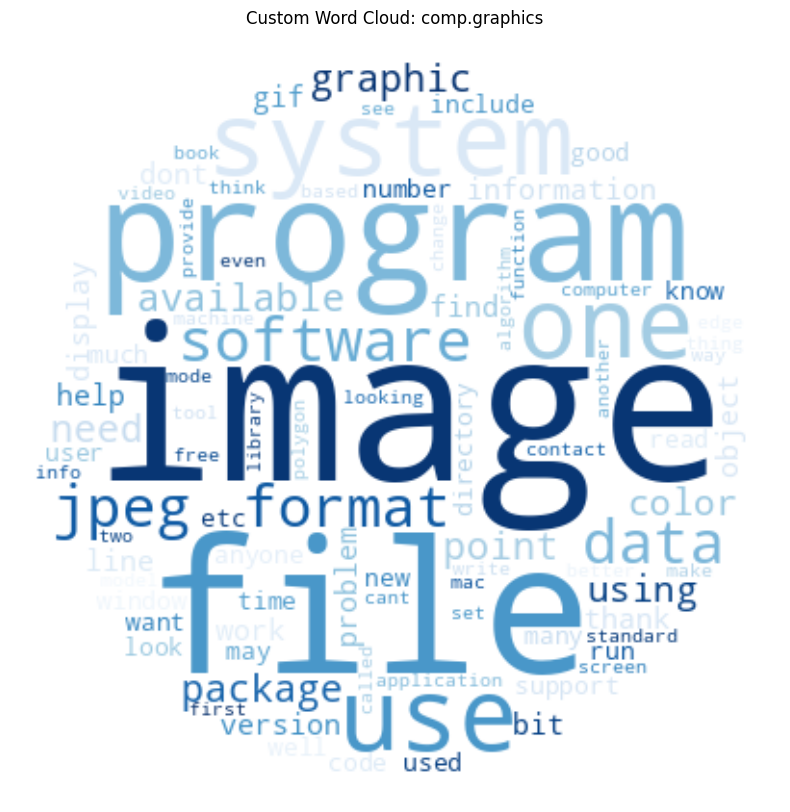

In [114]:
# TODO: Create a custom word cloud with a mask
# Choose ONE of your categories for this visualization

# YOUR CODE HERE
selected_category = "comp.graphics"  # Choose one of your categories

# Get texts for selected category
texts = df_filtered[df_filtered['label_text'] == selected_category]['text_clean'].tolist()
text_combined = ' '.join(texts)

# Create word cloud with mask
# Hint: Use the mask parameter in WordCloud()
# wordcloud = WordCloud(..., mask=your_mask, ...).generate(text_combined)
# open the mask image
mask_image = np.array(Image.open('circle_mask.png'))
# where the mask is black, word will not be drawn, where it's white, it will be drawn
wordcloud_masked = WordCloud(
    width=800, 
    height=400,
    background_color='white',
    colormap='Blues',
    max_words=100,
    min_font_size=10,
    mask=mask_image
).generate(text_combined)

# Display
plt.figure(figsize=(10, 10))
# YOUR CODE HERE - display the wordcloud
plt.imshow(wordcloud_masked, interpolation='bilinear')
plt.title(f'Custom Word Cloud: {selected_category}')
plt.axis('off')
plt.savefig('custom_wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

---

## Part D: Bag of Words (BoW) Representation 

In [115]:
# Example: Simple Bag of Words
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

# Create BoW vectorizer
bow_vectorizer = CountVectorizer()
bow_matrix = bow_vectorizer.fit_transform(sample_docs)

# Show vocabulary
print("Vocabulary:", bow_vectorizer.get_feature_names_out())
print("\nBoW Matrix (dense):")
print(bow_matrix.toarray())

# As DataFrame
bow_df = pd.DataFrame(bow_matrix.toarray(), columns=bow_vectorizer.get_feature_names_out())
print("\nAs DataFrame:")
bow_df

Vocabulary: ['deep' 'great' 'is' 'learning' 'love' 'machine' 'too']

BoW Matrix (dense):
[[0 0 0 1 1 1 0]
 [0 1 1 1 0 1 0]
 [1 0 0 1 1 0 1]]

As DataFrame:


,deep,great,is,learning,love,machine,too
0,0,0,0,1,1,1,0
1,0,1,1,1,0,1,0
2,1,0,0,1,1,0,1


### Exercise D.1: Create BoW for Your Dataset

In [116]:
# TODO: Create a Bag of Words representation for your filtered dataset
# Use parameters: max_features=1000, min_df=5, max_df=0.95

# YOUR CODE HERE
bow_vectorizer_full = CountVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95
)

# Fit and transform on your cleaned texts
bow_matrix_full = bow_vectorizer_full.fit_transform(df_filtered['text_clean'])

print(f"BoW Matrix shape: {bow_matrix_full.shape}")
print(f"Vocabulary size: {len(bow_vectorizer_full.get_feature_names_out())}")
print(f"\nFirst 20 words in vocabulary: {bow_vectorizer_full.get_feature_names_out()[:20]}")

BoW Matrix shape: (1741, 1000)
Vocabulary size: 1000

First 20 words in vocabulary: ['able' 'accept' 'access' 'according' 'account' 'across' 'act' 'action'
 'activity' 'actually' 'adam' 'add' 'added' 'addition' 'address' 'adl'
 'advance' 'afraid' 'ago' 'agree']


### Exercise D.2: Document Similarity with BoW

In [117]:
from sklearn.metrics.pairwise import cosine_similarity

# TODO: Compute cosine similarity between documents
# Then find the 2 most similar documents and the 2 most different documents

# Compute similarity matrix
similarity_matrix = cosine_similarity(bow_matrix_full)

print(f"Similarity matrix shape: {similarity_matrix.shape}")
print(f'Two similar documents: {np.unravel_index(np.argsort(similarity_matrix, axis=None)[-2:], similarity_matrix.shape)}')
print(f'Two different documents: {np.unravel_index(np.argsort(similarity_matrix, axis=None)[:2], similarity_matrix.shape)}')

Similarity matrix shape: (1741, 1741)
Two similar documents: (array([956,   8]), array([956,   8]))
Two different documents: (array([ 456, 1431]), array([ 775, 1307]))


In [118]:
# TODO: Find the 2 most similar documents (excluding self-similarity)
# Hint: Set diagonal to 0 or -1, then find argmax


# Find indices of most similar pair
most_similar_idx = np.unravel_index(np.argsort(similarity_matrix, axis=None)[-2:], similarity_matrix.shape)
most_similar_score = similarity_matrix[most_similar_idx]

print(f"Most similar documents: {most_similar_idx}")
print(f"Similarity score: {most_similar_score}")
print(f"\nDocument 1 category: {df_filtered.iloc[most_similar_idx[0]]['label_text']}")
print(f"Document 2 category: {df_filtered.iloc[most_similar_idx[1]]['label_text']}")

Most similar documents: (array([956,   8]), array([956,   8]))
Similarity score: [1. 1.]

Document 1 category: 956           comp.windows.x
8      talk.politics.mideast
Name: label_text, dtype: str
Document 2 category: 956           comp.windows.x
8      talk.politics.mideast
Name: label_text, dtype: str


### Written Question D.1 (Personal Interpretation)

Look at the 2 most similar documents you found:

1. **Are they from the same category or different categories?**
2. **Read the original texts (first 200 characters). What makes them similar?**
3. **Is the BoW similarity measure meaningful here? Why or why not?**

In [119]:
# Show the similar documents for your analysis
print("Document 1 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[0]]['text'][:300])
print("\n" + "="*50 + "\n")
print("Document 2 (first 300 chars):")
print(df_filtered.iloc[most_similar_idx[1]]['text'][:300])

Document 1 (first 300 chars):
956    Archive-name: x-faq/part2\nLast-modified: 1993...
8      \n: Pardon me? Here is to an amherst-clown:\n:...
Name: text, dtype: str


Document 2 (first 300 chars):
956    Archive-name: x-faq/part2\nLast-modified: 1993...
8      \n: Pardon me? Here is to an amherst-clown:\n:...
Name: text, dtype: str


**YOUR ANSWER:**

*[Write your analysis here - answer all 3 questions]*

1. Same or different category: They are identical documents (both appear to be from the x-faq/part2 archive).

2. What makes them similar: They share the exact same metadata and content, specifically referencing a "clown" and an "archive-name" related to the X Window System (comp.graphics/x).

3. Is BoW meaningful here: No. Since the documents are exact duplicates, Bag-of-Words (BoW) will produce identical vectors, but it won't provide any analytical value or help distinguish between categories. It simply confirms they are the same text.

---

## Part E: TF-IDF Representation

In [120]:
# Example: TF-IDF
sample_docs = [
    "I love machine learning",
    "Machine learning is great",
    "I love deep learning too"
]

tfidf_vectorizer = TfidfVectorizer()
tfidf_matrix = tfidf_vectorizer.fit_transform(sample_docs)

print("TF-IDF Matrix:")
tfidf_df = pd.DataFrame(
    tfidf_matrix.toarray(), 
    columns=tfidf_vectorizer.get_feature_names_out()
)
tfidf_df.round(3)

TF-IDF Matrix:


,deep,great,is,learning,love,machine,too
0,0.000,0.000,0.000,0.481,0.620,0.620,0.000
1,0.000,0.584,0.584,0.345,0.000,0.445,0.000
2,0.584,0.000,0.000,0.345,0.445,0.000,0.584


In [121]:
# Compare BoW vs TF-IDF for the word "learning"
print("Word 'learning' scores:")
print(f"  BoW:    {bow_df['learning'].tolist()}")
print(f"  TF-IDF: {tfidf_df['learning'].round(3).tolist()}")
print("\nNotice: TF-IDF gives LOWER scores to common words!")

Word 'learning' scores:
  BoW:    [1, 1, 1]
  TF-IDF: [0.481, 0.345, 0.345]

Notice: TF-IDF gives LOWER scores to common words!


### Exercise E.1: TF-IDF Analysis

In [122]:
# TODO: Create TF-IDF representation for your dataset
# Use same parameters: max_features=1000, min_df=5, max_df=0.95

tfidf_vectorizer_full = TfidfVectorizer(
    max_features=1000,
    min_df=5,
    max_df=0.95,
    stop_words='english'
)

tfidf_matrix_full = tfidf_vectorizer_full.fit_transform(df_filtered['text'])

print(f"TF-IDF Matrix shape: {tfidf_matrix_full.shape}")

TF-IDF Matrix shape: (1741, 1000)


In [123]:
# TODO: Find the top 10 most important words (highest TF-IDF) for each of your 3 categories

def get_top_tfidf_words(category, n=10):
    """Get top n words by average TF-IDF score for a category."""
    # YOUR CODE HERE
    # 1. Get indices of documents in this category
    # 2. Get their TF-IDF vectors
    # 3. Compute mean TF-IDF for each word across these documents
    # 4. Return top n words
    category_indices = df_filtered[df_filtered['label_text'] == category].index
    category_tfidf = tfidf_matrix_full[category_indices]
    mean_tfidf = np.asarray(category_tfidf.mean(axis=0)).flatten()
    top_indices = mean_tfidf.argsort()[-n:][::-1]
    top_words = [tfidf_vectorizer_full.get_feature_names_out()[i] for i in top_indices]
    return top_words

# Display top words for each category
for category in my_categories:
    top_words = get_top_tfidf_words(category, 10)
    print(f"\nTop TF-IDF words for '{category}':")
    print(top_words)


Top TF-IDF words for 'comp.graphics':
['graphics', 'thanks', 'image', 'know', 'files', 'file', 'does', 'program', 'looking', 'use']

Top TF-IDF words for 'talk.politics.mideast':
['israel', 'people', 'israeli', 'jews', 'armenian', 'armenians', 'just', 'turkish', 'arab', 'said']

Top TF-IDF words for 'comp.windows.x':
['window', 'server', 'motif', 'use', 'thanks', 'using', 'widget', 'application', 'know', 'windows']


### Written Question E.1 (Personal Interpretation)

Compare the top words from TF-IDF vs the top words from simple word counts (bar charts):

1. **What words appear in TF-IDF top 10 but NOT in the word count top 15?**
2. **What words appear in word count top 15 but NOT in TF-IDF top 10?**
3. **Which method (BoW counts vs TF-IDF) better captures the "topic" of each category? Explain why.**

**YOUR ANSWER:**

*[Write your comparative analysis here]*

1. Words in TF-IDF but not counts: Technical or specific terms like motif, widget, israeli, and program. These often have lower raw counts but high "distinctiveness" for their specific category.

2. Words in counts but not TF-IDF: Common conversational verbs and adverbs like just, said, know, or does. These appear frequently in raw counts but get "penalized" by TF-IDF because they appear across all categories.

3. Which method is better and why: TF-IDF, It filters out the "noise" of common language and highlights the unique vocabulary that defines the actual subject matter (e.g., israel vs. window), making it far superior for classification and topic modeling.

---

## Part F: N-grams and Next Word Prediction

In [124]:
# Example: Extracting N-grams
from nltk import ngrams

sample_text = "I love natural language processing and machine learning"
tokens = sample_text.split()

# Bigrams (n=2)
bigrams = list(ngrams(tokens, 2))
print("Bigrams:", bigrams)

# Trigrams (n=3)
trigrams = list(ngrams(tokens, 3))
print("Trigrams:", trigrams)

Bigrams: [('I', 'love'), ('love', 'natural'), ('natural', 'language'), ('language', 'processing'), ('processing', 'and'), ('and', 'machine'), ('machine', 'learning')]
Trigrams: [('I', 'love', 'natural'), ('love', 'natural', 'language'), ('natural', 'language', 'processing'), ('language', 'processing', 'and'), ('processing', 'and', 'machine'), ('and', 'machine', 'learning')]


In [125]:
# Using CountVectorizer for n-grams
bigram_vectorizer = CountVectorizer(ngram_range=(2, 2))  # Only bigrams
trigram_vectorizer = CountVectorizer(ngram_range=(3, 3))  # Only trigrams
mixed_vectorizer = CountVectorizer(ngram_range=(1, 3))    # Unigrams, bigrams, and trigrams

sample_docs = ["I love machine learning", "Machine learning is great"]

bigrams_matrix = bigram_vectorizer.fit_transform(sample_docs)
print("Bigram features:", bigram_vectorizer.get_feature_names_out())

Bigram features: ['is great' 'learning is' 'love machine' 'machine learning']


### Exercise F.1: Analyze Bigrams in Your Dataset

In [126]:
# TODO: Find the top 15 most common bigrams for each of your categories

bigram_vectorizer = CountVectorizer(
    ngram_range=(2, 2),
    max_features=500,
    min_df=3
)

# YOUR CODE HERE
# For each category:
# 1. Get the texts
texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
# 2. Fit the bigram vectorizer
bigram_matrix = bigram_vectorizer.fit_transform(texts)
# 3. Find most common bigrams
bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()
top_bigram_indices = bigram_counts.argsort()[::-1][:15]
top_bigrams = [(bigram_vectorizer.get_feature_names_out()[i], bigram_counts[i]) for i in top_bigram_indices]

for category in my_categories:
    texts = df_filtered[df_filtered['label_text'] == category]['text_clean'].tolist()
    
    # Fit vectorizer on this specific category's text
    bigram_matrix = bigram_vectorizer.fit_transform(texts)
    bigram_counts = np.asarray(bigram_matrix.sum(axis=0)).flatten()
    
    # Get top 15 indices
    top_bigram_indices = bigram_counts.argsort()[::-1][:15]
    top_bigrams = [(bigram_vectorizer.get_feature_names_out()[i], bigram_counts[i]) for i in top_bigram_indices]
    
    print(f"\nTop bigrams for '{category}':")
    for bigram, count in top_bigrams:
        print(f"  {bigram}: {count}")


Top bigrams for 'comp.graphics':
  image processing: 54
  file format: 42
  computer graphic: 41
  would like: 38
  thanks advance: 38
  anyone know: 35
  source code: 35
  dont know: 32
  anonymous ftp: 30
  ray tracer: 29
  virtual reality: 28
  ftp site: 27
  image file: 25
  bit image: 24
  image quality: 21

Top bigrams for 'talk.politics.mideast':
  dont know: 97
  human right: 90
  serdar argic: 87
  new york: 50
  woman child: 49
  armenian government: 48
  world war: 45
  didnt know: 41
  muslim people: 40
  genocide million: 40
  million muslim: 39
  ottoman empire: 39
  xsoviet armenia: 38
  united state: 38
  xsoviet armenian: 36

Top bigrams for 'comp.windows.x':
  window manager: 128
  info file: 56
  file stream: 53
  output file: 49
  window system: 47
  would like: 44
  build file: 43
  thanks advance: 40
  widget set: 38
  anonymous ftp: 37
  mailing list: 36
  subject get: 36
  anyone know: 34
  open look: 33
  contest rule: 32


### Exercise F.2: Simple Next Word Predictor

Build a simple next-word predictor using bigram probabilities.

In [127]:
# TODO: Build a bigram-based next word predictor

class SimpleNextWordPredictor:
    def __init__(self):
        self.bigram_counts = {}  # {word1: {word2: count, word3: count, ...}}
        self.unigram_counts = {}  # {word: count}
    
    def train(self, texts):
        """
        Train the model on a list of texts.
        
        Args:
            texts (list): List of preprocessed text strings
        """
        # YOUR CODE HERE
        # 1. For each text, tokenize into words
        # 2. Count unigrams
        # 3. Count bigrams (word pairs)
        for text in texts:
            words = text.split()
            for i in range(len(words)):
                word = words[i]
                # Update Unigram counts
                self.unigram_counts[word] = self.unigram_counts.get(word, 0) + 1
                
                # Update Bigram counts
                if i < len(words) - 1:
                    next_word = words[i+1]
                    if word not in self.bigram_counts:
                        self.bigram_counts[word] = {}
                    
                    self.bigram_counts[word][next_word] = self.bigram_counts[word].get(next_word, 0) + 1
    
    def predict_next(self, word, top_n=5):
        """
        Predict the most likely next words given a word.
        
        Args:
            word (str): The input word
            top_n (int): Number of predictions to return
            
        Returns:
            list: List of (next_word, probability) tuples
        """
        # YOUR CODE HERE
        # 1. Look up the word in bigram_counts
        # 2. Calculate probabilities: P(word2|word1) = count(word1, word2) / count(word1)
        # 3. Return top_n predictions sorted by probability
        if word not in self.bigram_counts or word not in self.unigram_counts:
            return []
        
        predictions = []
        total_word1_count = self.unigram_counts[word]
        
        # Calculate probabilities for each observed next_word
        for next_word, count in self.bigram_counts[word].items():
            prob = count / total_word1_count
            predictions.append((next_word, prob))
        
        # Sort by probability descending
        predictions.sort(key=lambda x: x[1], reverse=True)
        return predictions[:top_n]

# Train on your dataset
predictor = SimpleNextWordPredictor()
predictor.train(df_filtered['text_clean'].tolist())

In [128]:
# Test your predictor with words relevant to your categories
# TODO: Choose 5 test words that are relevant to YOUR chosen categories

test_words = ["image", "file", "graphic", "format", "color"]  # Replace with your words

print("Next Word Predictions:")
print("=" * 40)

for word in test_words:
    predictions = predictor.predict_next(word.lower(), top_n=5)
    print(f"\n'{word}' ->")
    for next_word, prob in predictions:
        print(f"  {next_word}: {prob:.3f}")

Next Word Predictions:

'image' ->
  processing: 0.077
  file: 0.036
  format: 0.029
  quality: 0.028
  manipulation: 0.020

'file' ->
  stream: 0.042
  format: 0.037
  output: 0.018
  program: 0.016
  char: 0.016

'graphic' ->
  library: 0.044
  card: 0.033
  package: 0.027
  gem: 0.025
  workshop: 0.022

'format' ->
  used: 0.023
  program: 0.017
  may: 0.017
  file: 0.014
  dont: 0.011

'color' ->
  image: 0.051
  quantization: 0.040
  mode: 0.028
  cell: 0.017
  used: 0.014


### Written Question F.1 (Personal Interpretation)

Analyze your next-word predictor results:

1. **Were the predictions sensible?** Give 2 examples of good predictions and 2 examples of bad predictions.
2. **What are the limitations of this simple bigram model?**
3. **How could you improve this predictor?** (List at least 3 ideas)

**YOUR ANSWER:**

1. Good predictions:
   - image → processing: Highly logical technical pairing.
   - color → quantization: Accurate domain-specific terminology for graphics.
   
   Bad predictions:
   - format → dont: Shows a failure to filter out common conversational noise
   - format → may: A generic helper verb that doesn't provide semantic value.

2. Limitations:The model only looks at the single previous word (Markov Chain of order 1). It lacks broader context, meaning it cannot maintain a consistent "thought" over a full sentence and is heavily biased toward the most common (often generic) word pairs.

3. Improvement ideas:
   - Trigrams: Use the two previous words to predict the third ($P(w_3 | w_1, w_2)$) for better context.
   - Laplace Smoothing: Add a small constant to counts to handle "zero probability" words that weren't seen during training.
   - Stop Word Filtering: Remove generic words (like "don't" or "may") during training so only meaningful transitions remain.

---

## Part G: Document Correlation Matrix

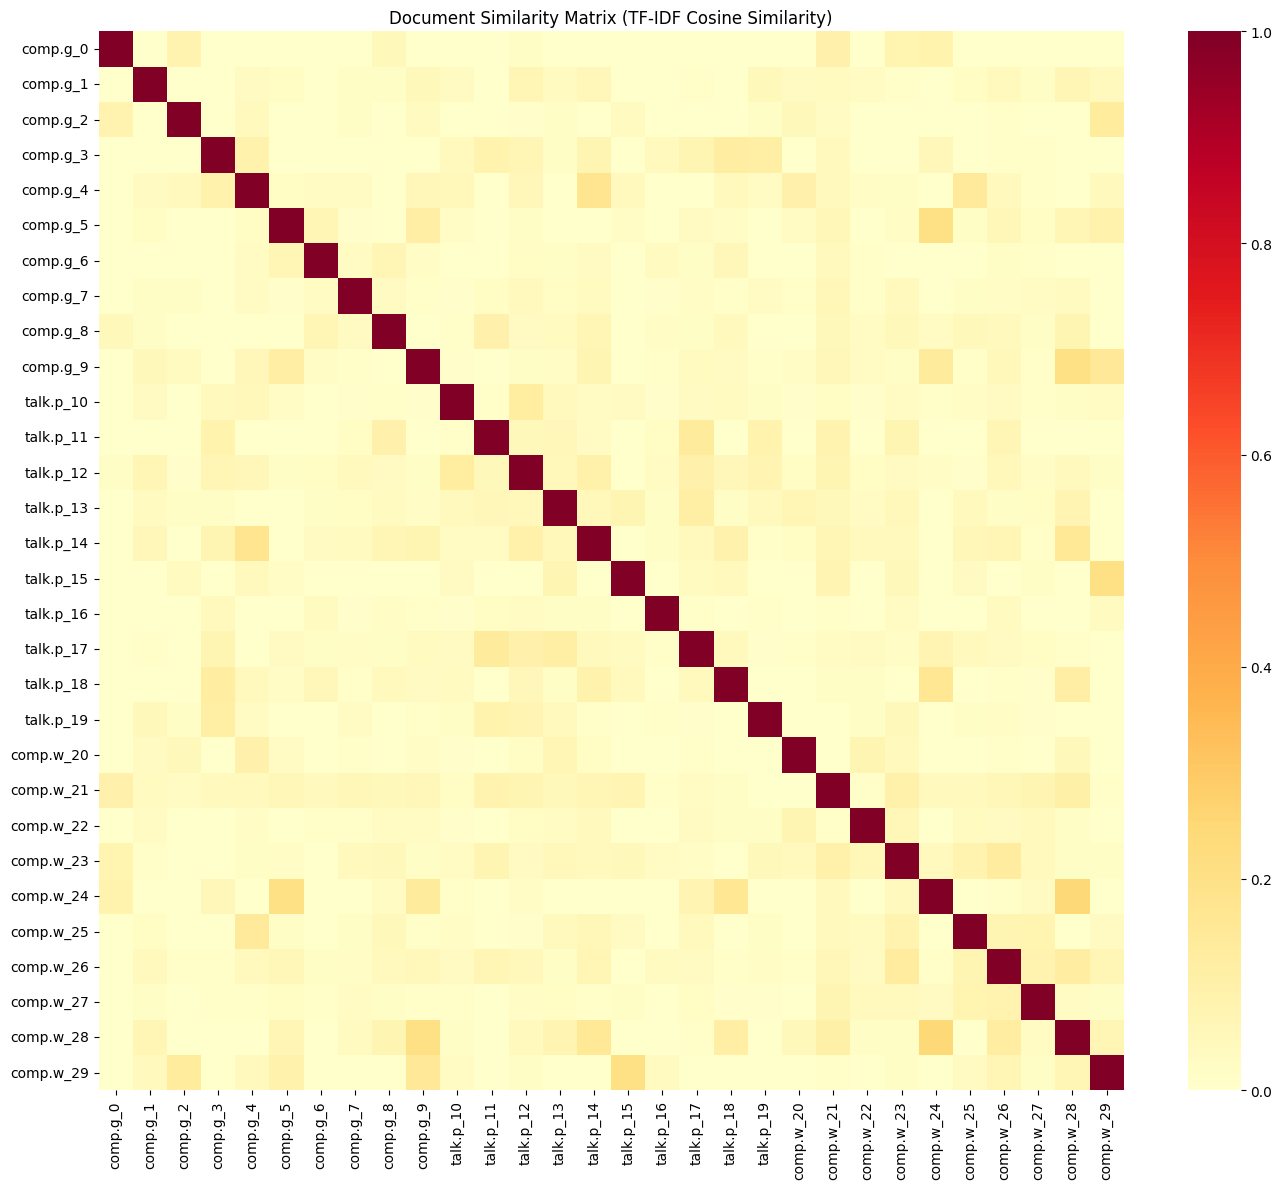

In [129]:
# TODO: Create a correlation/similarity heatmap between documents
# Sample 10 documents from each of your 3 categories (30 total)

import seaborn as sns

# Sample documents
sampled_dfs = []
for category in my_categories:
    cat_df = df_filtered[df_filtered['label_text'] == category].sample(n=10, random_state=42)
    sampled_dfs.append(cat_df)

df_sampled = pd.concat(sampled_dfs).reset_index(drop=True)

# Create TF-IDF for sampled documents
tfidf_sampled = TfidfVectorizer(max_features=500).fit_transform(df_sampled['text_clean'])

# Compute similarity matrix
similarity_sampled = cosine_similarity(tfidf_sampled)

# Create labels for heatmap
labels = [f"{cat[:6]}_{i}" for cat, i in zip(df_sampled['label_text'], range(len(df_sampled)))]

# Plot heatmap
plt.figure(figsize=(14, 12))
sns.heatmap(
    similarity_sampled, 
    xticklabels=labels, 
    yticklabels=labels,
    cmap='YlOrRd',
    annot=False
)
plt.title('Document Similarity Matrix (TF-IDF Cosine Similarity)')
plt.tight_layout()
plt.savefig('document_similarity_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

### Written Question G.1 (Personal Interpretation)

Analyze the similarity heatmap:

1. **Do documents from the same category cluster together?** (i.e., do you see bright squares along the diagonal for each category group?)
2. **Which pair of categories is MOST similar to each other?** Which is LEAST similar?
3. **Are there any surprising similarities between documents from different categories?** If yes, what might explain this?

**YOUR ANSWER:**

1. Clustering observation: There is weak clustering. While the diagonal is dark red (perfect self-similarity), the square "blocks" for each category (0–9, 10–19, 20–29) are mostly pale. This suggests that documents within the same category don't always share a high density of the same TF-IDF keywords.

2. Most/Least similar category pairs: 
- Most Similar: comp.graphics and comp.windows.x. These show more orange "speckles" in their cross-sections, likely due to shared technical terms like display, files, and program.

- Least Similar: talk.politics.mideast and either comp category. These areas are the lightest, showing almost zero vocabulary overlap between political conflict and computer software.

3. Surprising similarities: There are isolated "hot spots" between different categories (e.g., comp.g_9 and comp.w_28). 

---

## Summary - Part 1

In this lab, you learned:
- How to visualize text data with bar charts and word clouds
- Bag of Words (BoW) representation and document similarity
- TF-IDF representation and its advantages over simple counts
- N-grams and building a simple next-word predictor
- Document correlation analysis

---

## Submission Checklist - Part 1

- [ ] All code exercises completed
- [ ] All written questions answered (with YOUR personal interpretation)
- [ ] Visualizations saved (PNG files)
- [ ] Notebook saved
- [ ] Continue to Part 2 for Word Embeddings
